In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import Compose, Normalize, ToTensor
from torch.utils.data import DataLoader
from torch.nn import init
import matplotlib.pyplot as plt
device = 'cuda:0'

In [2]:
# only has train and test set
# 1D data, so mean and std parameter contain only one element.
data_transform = Compose(transforms=[ToTensor(),
                                     Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# prepare data
trainset = CIFAR10(root='data',
                        train=True,
                        transform=data_transform,
                        download=True)

testset = CIFAR10(root='data',
                       train=False,
                       transform=data_transform)

# convert to DataLoader. Shuffle train set and doesn't turn on it for test set
trainloader = DataLoader(dataset=trainset,
                         batch_size=1024,
                         shuffle=True,
                         num_workers=10,
                         drop_last=True)

testloader = DataLoader(dataset=testset,
                        batch_size=1024,
                        shuffle=False,
                        num_workers=10,
                        drop_last=True)

# for debug
for _, (X_sample,y_sample) in enumerate(trainloader):
    print(X_sample.shape, y_sample.shape)
    break

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([1024, 3, 32, 32]) torch.Size([1024])


In [3]:
# VGG-16 building

# for CiFAR-10
input_dims = 3
output_dims = 10

# input: (3, 32, 32). Output: (64, 16, 16)
block1 = nn.Sequential(
    nn.Conv2d(in_channels=input_dims, out_channels=64, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2)
)

# Output: (128, 8, 8)
block2 = nn.Sequential(
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2)
)

# Output: (256, 4, 4)
block3 = nn.Sequential(
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2)
)

# Output: (512, 2, 2)
block4 = nn.Sequential(
    nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2)
)

# Output: (512, 1, 1)
block5 = nn.Sequential(
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.ReLU(inplace=True),
    nn.MaxPool2d(2, 2)
)

H, W = 1, 1
dense_block = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=512*H*W, out_features=4096), nn.ReLU(inplace=True),
    nn.Linear(in_features=4096, out_features=4096), nn.ReLU(inplace=True),
    nn.Linear(in_features=4096, out_features=output_dims)
)

class VGG16(nn.Module):
    def __init__(self):
        super(VGG16, self).__init__()
        self.block1 = block1
        self.block2 = block2
        self.block3 = block3
        self.block4 = block4
        self.block5 = block5
        self.dense = dense_block

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.dense(x)
        return x

model = VGG16().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)

In [4]:

def acc(logits_matrix, true_label_vector):
    """
    Calculate accuracy for model
    - logits_matrix:        a matrix which haves num_of_batch rows, and num_classes columns.
    - true_label_vector:    a vector contains true class of all samples in batch.
    """
    # get max value for each rows
    maxxing_vector = torch.argmax(logits_matrix, dim=1)

    # get the similar numbers between true and pred label, then calculates sum
    sum_elements = len(true_label_vector)
    similar_elements = (maxxing_vector == true_label_vector).sum()

    # accuracy
    acc_value = similar_elements/sum_elements
    return acc_value

In [5]:

# training
epochs = 150
train_losses = []
test_losses = []
train_accs = []
test_accs = []
for epoch in range(epochs):

    # batch logging
    train_loss_batches = []
    test_loss_batches = []
    train_acc_batches = []
    test_acc_batches = []
    #--------train field--------#
    model.train()
    for _, (X_train_batch, y_train_batch) in enumerate(trainloader):

        # transform to GPU
        X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)

        # forward
        y_train_batch_pred = model(X_train_batch)                # output: logits matrix
        train_loss_batch = criterion(y_train_batch_pred, y_train_batch)

        # backward
        optimizer.zero_grad()
        train_loss_batch.backward()
        optimizer.step()

        # save loss result
        loss_batch_value = train_loss_batch.item()
        train_loss_batches.append(loss_batch_value)

        # save metric result
        try:
            train_acc_batch = acc(logits_matrix=y_train_batch_pred,
                              true_label_vector= y_train_batch)
            train_acc_batches.append(train_acc_batch)

        except Exception as e:
            print(f'Failed to calculate metric for training: {e}')


    # loss: train epoch logging
    train_loss_epoch = sum(train_loss_batches)/len(train_loss_batches)
    train_losses.append(train_loss_epoch)

    # metric: train epoch logging
    train_acc_epoch = sum(train_acc_batches)/len(train_acc_batches)
    train_accs.append(train_acc_epoch)


    #---------test field--------#
    model.eval()
    for _, (X_test_batch, y_test_batch) in enumerate(testloader):

        # transform to GPU
        X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)

        # testing
        y_test_batch_pred = model(X_test_batch)
        test_loss_batch = criterion(y_test_batch_pred, y_test_batch)

        # save loss result
        test_loss_batch_value = test_loss_batch.item()
        test_loss_batches.append(test_loss_batch_value)

        # save metric result
        test_acc_batch = acc(logits_matrix=y_test_batch_pred,
                             true_label_vector=y_test_batch)
        test_acc_batches.append(test_acc_batch)


    # loss: test epoch logging
    test_loss_epoch = sum(test_loss_batches)/len(test_loss_batches)
    test_losses.append(test_loss_epoch)

    # metric: test epoch logging
    test_acc_epoch = sum(test_acc_batches)/len(test_acc_batches)
    test_accs.append(test_acc_epoch)


    # log
    print(f'EPOCH {epoch + 1}:           train_loss = {train_loss_epoch},                 test_loss = {test_loss_epoch}')

EPOCH 1:           train_loss = 2.3031773269176483,                 test_loss = 2.3026090463002524
EPOCH 2:           train_loss = 2.20852022866408,                 test_loss = 2.0538908110724554
EPOCH 3:           train_loss = 1.9781558190782864,                 test_loss = 1.883826904826694
EPOCH 4:           train_loss = 1.849248468875885,                 test_loss = 1.8176647822062175
EPOCH 5:           train_loss = 1.7903092876076698,                 test_loss = 1.8098714881473117
EPOCH 6:           train_loss = 1.7452557211120923,                 test_loss = 1.70321344004737
EPOCH 7:           train_loss = 1.6659142499168713,                 test_loss = 1.6219945748647053
EPOCH 8:           train_loss = 1.6154388537009556,                 test_loss = 1.5635511345333524
EPOCH 9:           train_loss = 1.5338351254661877,                 test_loss = 1.4760868549346924
EPOCH 10:           train_loss = 1.4616212447484334,                 test_loss = 1.418390737639533
EPOCH 11:       

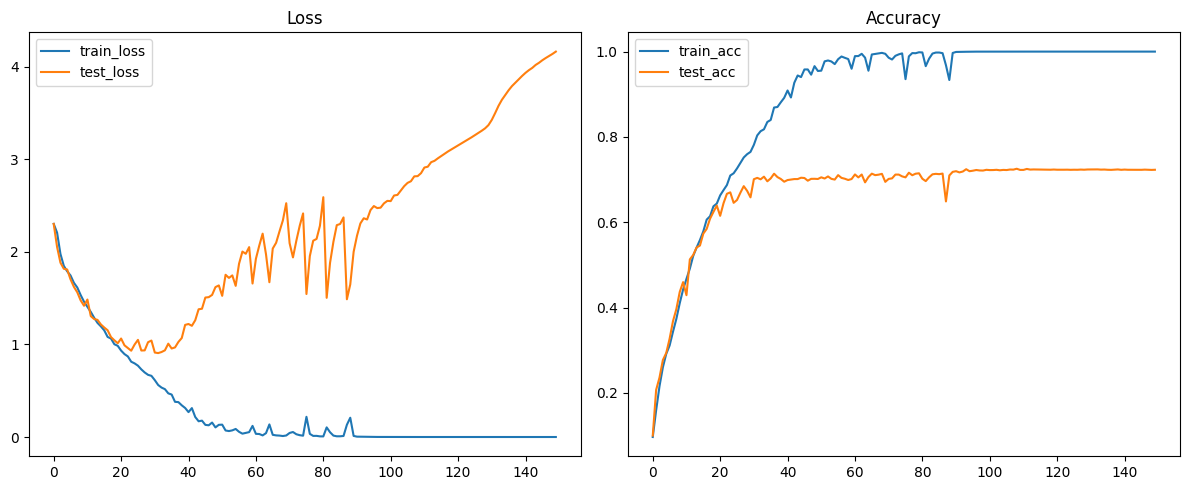

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
ax1.plot([t.item() if torch.is_tensor(t) else t for t in train_losses], label='train_loss')
ax1.plot([t.item() if torch.is_tensor(t) else t for t in test_losses], label='test_loss')
ax1.legend()
ax1.set_title("Loss")

# Accuracy plot
ax2.plot([t.item() if torch.is_tensor(t) else t for t in train_accs], label='train_acc')
ax2.plot([t.item() if torch.is_tensor(t) else t for t in test_accs], label='test_acc')
ax2.legend()
ax2.set_title("Accuracy")

plt.tight_layout()
plt.show()

In [7]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", total_params)
print("Trainable:", trainable_params)

Total parameters: 33638218
Trainable: 33638218
